In [59]:
import seaborn as sns
import pandas as pd
# Loading titanic dataset
df = sns.load_dataset('titanic')
print(df.head())
print(df.shape)
df.info()
# Create problems
df.loc[0, 'embark_town'] = 'southampton'
df.loc[1, 'embark_town'] = 'southampton'
print(df['embark_town'].unique())
df['embark_town'] = df['embark_town'].str.title()
# Create Duplicate records
duplicate_rows = df.iloc[:5]
df_dup = pd.concat([df, duplicate_rows])
print(df_dup.shape)
# Find duplicates
print(df_dup.duplicated().sum())
#View Duplicate Rows
df_dup[df_dup.duplicated()]
# Remove Duplicated
df_dup = df_dup.drop_duplicates()
print(df_dup.duplicated().sum())
#Typos
df.loc[0, 'embark_town'] = 'southampton'
df.loc[1, 'embark_town'] = 'Southhampton'
print(df['embark_town'].value_counts())
# Fix Typos
df['embark_town'] = df['embark_town'].replace({
    'sounthamton': 'sounthamton',
    'Sounthhamton': 'Sounthamton'
})
# Verify
print(df['embark_town'].value_counts())
#Detect Possible Tyops
print(sorted(df['embark_town'].dropna().unique()))
df.loc[0, 'age'] = 240
df.loc[1, 'age'] = 300
# Deduct unusual values
df['age'].describe()
# Fix unit mismatch
# Convert months to years
df.loc[df['age'] > 120,'age'] = (
    df.loc[df['age'] > 120,'age'] / 12
)
# Verify
df['age'].describe()

df['survived_label'] = df['survived'].map({
    0:'No',
    1:'Yes'
})
print(df.head(10))
# Redudent Columns(used to remove unwanted columns)
#Check
df.isnull().mean()
# Remove
df.drop(columns=['deck'], inplace=True)
df.head()

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     

# Handeling null values

In [68]:
# Method 1: Mean Imputation
#Replace missing values with the average value.
df['age'] = df['age'].fillna(df['age'].mean())
df.head(20)

,age,fare
0,22.0,7.25
1,25.0,8.05
2,23.5,7.90
3,24.0,8.00
4,23.0,7.50


In [61]:
# Method 2: Median Imputation
# Replace missing values with the middle value
# If skew is high use median...if skew is normal use mean
# distribution = df['age'].skew()
df["age"]=df["age"].fillna(df["age"].median())
df.head(20)

,age,fare
0,22.0,7.25
1,25.0,8.05
2,23.5,7.90
3,24.0,8.00
4,23.0,7.50


In [63]:
#Method 3 : Mode imputation
#replace missing values with the average value
df["age"]=df["age"].fillna(df["age"].mode())
df.head()

,age,fare
0,22.0,7.25
1,25.0,8.05
2,23.5,7.90
3,24.0,8.00
4,23.0,7.50


In [65]:
#Method 4: Forward Fill(FFill)
#Use the previous value to fill missing data
#Before Imputation
#print(df["embarked"].isnull().sum())
#Apply Forward Fill
df["age_ffill"]=df["age"].ffill()
#check Missing Values
print(df["age_ffill"].isnull().sum())
df.head(20)

0


,age,fare,age_ffill
0,22.0,7.25,22.0
1,25.0,8.05,25.0
2,23.5,7.90,23.5
3,24.0,8.00,24.0
4,23.0,7.50,23.0


In [67]:
#Method 5: KNN Imputation
#K-Nearest Neighbours(KNN) Imputation fills missing values using information from similar rows
#Instead of using a single value(mean/median),it finds the K most similar records and uses their values
import pandas as pd
import numpy as np
data={
    "age":[22,25,np.nan,24,23],
    "fare":[7.25,8.05,7.90,8.00,7.50]
}
df=pd.DataFrame(data)
print(df)

    age  fare
0  22.0  7.25
1  25.0  8.05
2   NaN  7.90
3  24.0  8.00
4  23.0  7.50


In [69]:
import pandas as pd
import seaborn as sns
from sklearn.impute import KNNImputer
# Load Titanic dataset
df = sns.load_dataset('titanic')
# Forward Fill for embarked
df['embarked_ffill'] = df['embarked'].ffill()
# KNN Imputation for numeric columns
cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
imputer = KNNImputer(n_neighbors=5)
df[cols] = imputer.fit_transform(df[cols])
# Check missing values
print(df.isnull().sum())

survived            0
pclass              0
sex                 0
age                 0
sibsp               0
parch               0
fare                0
embarked            2
class               0
who                 0
adult_male          0
deck              688
embark_town         2
alive               0
alone               0
embarked_ffill      0
dtype: int64


# ENCODING

In [71]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
# Load Titanic dataset
df = sns.load_dataset('titanic')
# Label Encoding
le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['embarked'],
    #drop_first=True
)
# Target Encoding
target_map = df.groupby('pclass') ['survived'].mean()
df['class_target'] = (df['pclass'].map(target_map))
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare  class    who  \
0         0       3    male  22.0      1      0   7.2500  Third    man   
1         1       1  female  38.0      1      0  71.2833  First  woman   
2         1       3  female  26.0      0      0   7.9250  Third  woman   
3         1       1  female  35.0      1      0  53.1000  First  woman   
4         0       3    male  35.0      0      0   8.0500  Third    man   

   adult_male deck  embark_town alive  alone  sex_encoded  embarked_C  \
0        True  NaN  Southampton    no  False            1       False   
1       False    C    Cherbourg   yes  False            0        True   
2       False  NaN  Southampton   yes   True            0       False   
3       False    C  Southampton   yes  False            0       False   
4        True  NaN  Southampton    no   True            1       False   

   embarked_Q  embarked_S  class_target  
0       False        True      0.242363  
1       False       False      0

# Feature Scaling using Titanic Dataset

# MinMaxScaler 

In [77]:
# This transforms numerical features to a similar scale.
# 1.MinMaxScaler - prevents shape of distribution
# 2.StandardScaler - Centers data around mean = 0 and standard deviation = 1.
# 3.RobustScaler - Uses median and IQR instead of mean and standard deviation.

# 1.MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['age_minmax','fare_minmax']] = scaler.fit_transform(df[['age','fare']])
df[['age_minmax','fare_minmax']].head()

,age_minmax,fare_minmax
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


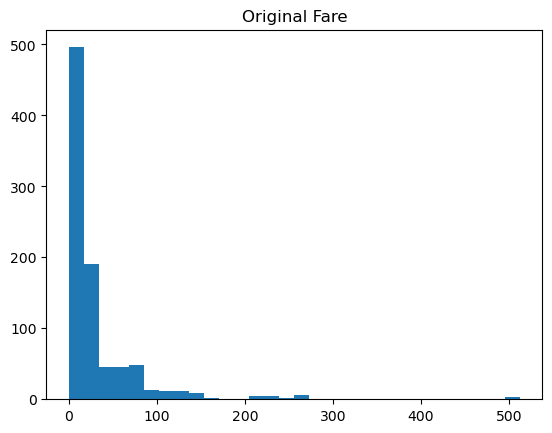

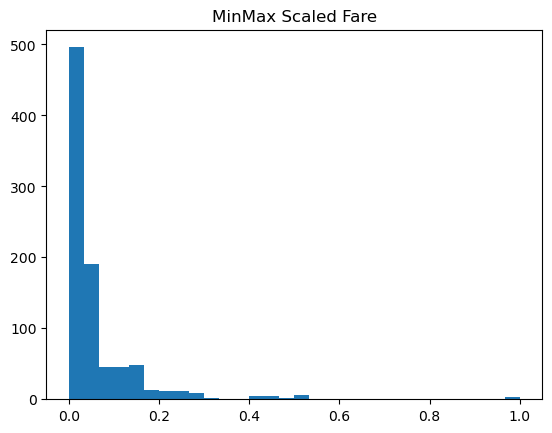

In [76]:
import matplotlib.pyplot as plt
plt.hist(df['fare'].dropna(), bins=30)
plt.title('Original Fare')
plt.show()
plt.hist(df['fare_minmax'].dropna(), bins=30)
plt.title('MinMax Scaled Fare')
plt.show()

# StandardScaler

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age_std','fare_std']] = scaler.fit_transform(df[['age','fare']])
df[['age_std','fare_std']].head()

,age_std,fare_std
0,-0.530377,-0.502445
1,0.571831,0.786845
2,-0.254825,-0.488854
3,0.365167,0.420730
4,0.365167,-0.486337


# RobustScaler

In [79]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[['age_robust','fare_robust']] = scaler.fit_transform(df[['age','fare']])
df[['age_robust','fare_robust']].head()

,age_robust,fare_robust
0,-0.335664,-0.312011
1,0.559441,2.461242
2,-0.111888,-0.282777
3,0.391608,1.673732
4,0.391608,-0.277363
